In [74]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/videogamesales/vgsales.csv


In [75]:
vg_file_path = '/kaggle/input/videogamesales/vgsales.csv'
vg_data = pd.read_csv(vg_file_path, index_col='Rank')
vg_data.columns

Index(['Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')

# 1. Understand the Problem
      A. Define the task: Is it regression (predicting continuous values) or classification (predicting discrete labels) --> **Regression**
   
   B. Ensure data contains input features (predictors) and target variable. --> We will be trying to predict what features impacts are target variable `Global_Sales`.

In [76]:
vg_data.shape #getting rows and column count of data to visualize our dataset

(16598, 10)

In [77]:
vg_data.head() #first 5 rows

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Rank,,,,,,,,,,
1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


# 2. Data Preprocessing

A. Handle Missing Data: Impute or drop missing values as needed. --> I dropped missing values from `Year` and imputed `Publisher`

B. Encode Categorical Variables: Use methods like OrdinalEncoder or OneHotEncoder. --> I used **OrdinalEncoder**

C. Feature Selection: Eliminate irrelevant features to improve model efficiency. --> I eliminated `Name`

D. Train-Test Split: Split data into training and validation sets. 

In [78]:
missing_vg_count_by_column = (vg_data.isnull().sum()) #checking the number of missing values in each column
print(missing_vg_count_by_column)
print(100 * missing_vg_count_by_column/vg_data.shape[0]) #calculating the percent of missing values to determine how to handle them

Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64
Name            0.000000
Platform        0.000000
Year            1.632727
Genre           0.000000
Publisher       0.349440
NA_Sales        0.000000
EU_Sales        0.000000
JP_Sales        0.000000
Other_Sales     0.000000
Global_Sales    0.000000
dtype: float64


We can keep both 'Year' and 'Publisher' because they have almost no effect on skewing the data (1.63% of data is missing for 'Year' and 0.35% for 'Publisher'). So, I can drop these values for 'Publisher' and impute 'Year'

In [79]:
vg_data.Publisher.dropna() #dropping missing values from Publisher

Rank
1          Nintendo
2          Nintendo
3          Nintendo
4          Nintendo
5          Nintendo
            ...    
16596         Kemco
16597    Infogrames
16598    Activision
16599      7G//AMES
16600       Wanadoo
Name: Publisher, Length: 16540, dtype: object

In [80]:
vg_data.Name.unique() 

array(['Wii Sports', 'Super Mario Bros.', 'Mario Kart Wii', ...,
       'Plushees', 'Woody Woodpecker in Crazy Castle 5', 'Know How 2'],
      dtype=object)

However, there are many values for name. I will show this when I use OrdinalEncoder and then drop this column.

In [81]:
print(vg_data)

                                                   Name Platform    Year  \
Rank                                                                       
1                                            Wii Sports      Wii  2006.0   
2                                     Super Mario Bros.      NES  1985.0   
3                                        Mario Kart Wii      Wii  2008.0   
4                                     Wii Sports Resort      Wii  2009.0   
5                              Pokemon Red/Pokemon Blue       GB  1996.0   
...                                                 ...      ...     ...   
16596                Woody Woodpecker in Crazy Castle 5      GBA  2002.0   
16597                     Men in Black II: Alien Escape       GC  2003.0   
16598  SCORE International Baja 1000: The Official Game      PS2  2008.0   
16599                                        Know How 2       DS  2010.0   
16600                                  Spirits & Spells      GBA  2003.0   

           

In [82]:
graphs_vg_data = vg_data
graphs_vg_data = graphs_vg_data.drop(columns=['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'])

To analyze the features in the dataset, I made a separate 'graphs_vg_data' to isolate the features from all of the sales. This will help visualize all the categorical variable and will help me determine which features I should keep. For example, according to the plots, I thought genre might be a good predictor of sales price because clearly some types of games are more consumed than others.

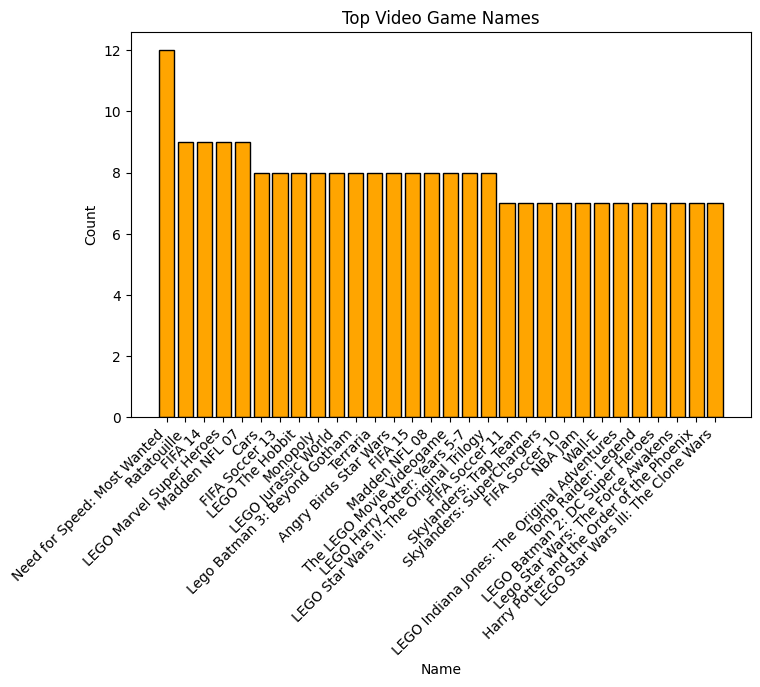

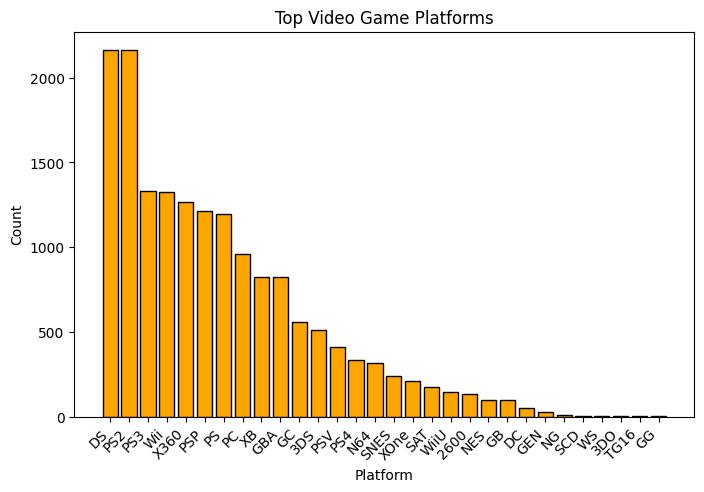

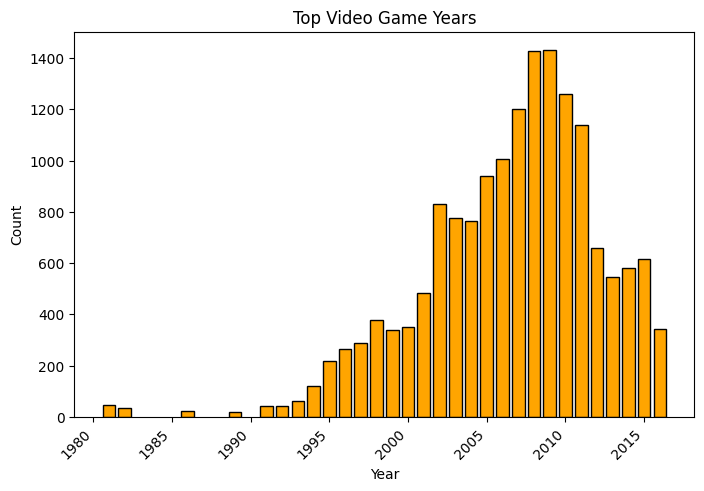

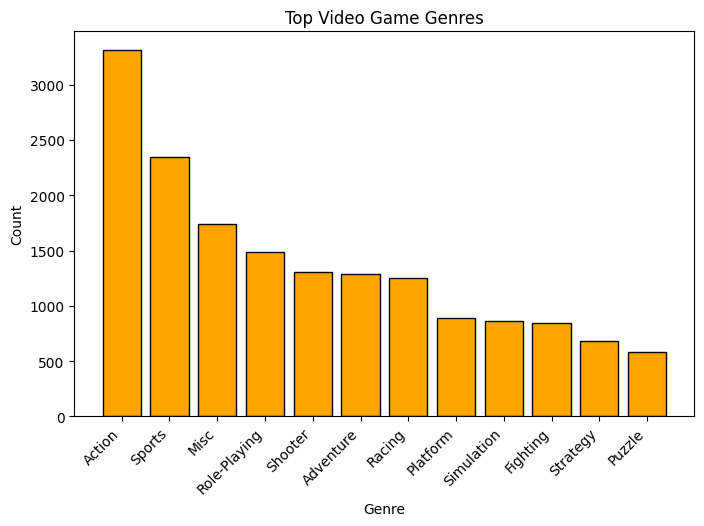

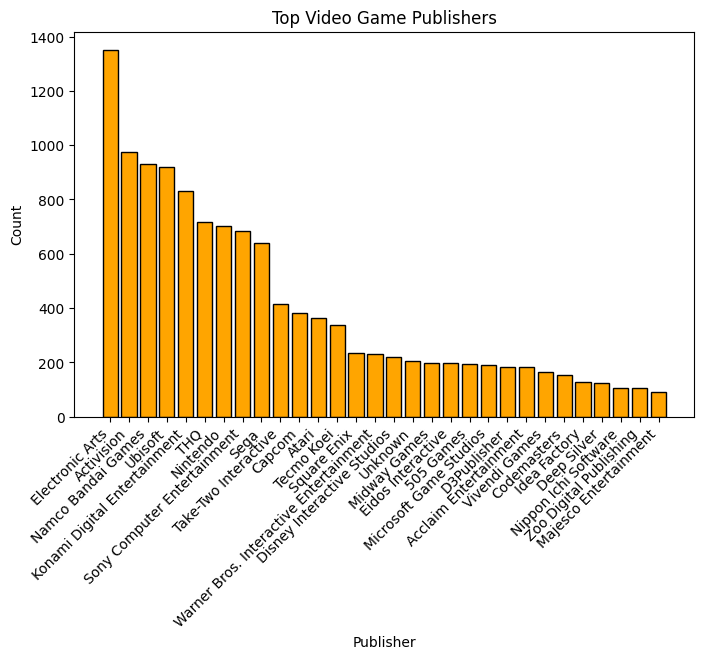

In [83]:
import matplotlib.pyplot as plt
import pandas as pd

cols = [col for col in graphs_vg_data.columns] #getting columns in graphs_vg_data


for col in cols:
    plt.figure(figsize=(8, 5))
    
    graphs_vg_data[col].nunique()
    data = graphs_vg_data[col].value_counts().head(30) #top 30 - if I were to add more then the graph would look much more chaotic
    plt.bar(data.index, data.values, color='orange', edgecolor='black')
    plt.title(f"Top Video Game {col}s")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha='right') #orientation of the x-axis labels, makes graphs look a lot more clear
    plt.show()

In [84]:
#getting the categorical columns in training data
object_cols = [col for col in X_train.columns if X_train[col].dtype == "object"]
print(object_cols)

[]


In [85]:
# Columns that will be encoded
low_cardinality_cols = [col for col in object_cols if X_train[col].nunique() < 1000]

# Columns that will be dropped from the dataset
high_cardinality_cols = list(set(object_cols)-set(low_cardinality_cols))

print('Categorical columns that will be encoded:', low_cardinality_cols)
print('\nCategorical columns that will be dropped from the dataset:', high_cardinality_cols)

Categorical columns that will be encoded: []

Categorical columns that will be dropped from the dataset: []


I just used a way to investigate the cardinality, which is simply the counting the number of elements or values in a set. As can be seen, there are still over 1000 unique values for name, which I felt was way too much to have a massive impact on the dataset. Though I will not be one-hot encoding, I found this useful in helping determine which categorical value I should drop.

In [86]:
good_object_cols = ['Platform', 'Genre', 'Publisher']
print(good_object_cols)

['Platform', 'Genre', 'Publisher']


In [87]:
from sklearn.preprocessing import OrdinalEncoder

label_vg = vg_data.copy()

# Apply ordinal encoder
ordinal_encoder = OrdinalEncoder()
label_vg[good_object_cols] = ordinal_encoder.fit_transform(vg_data[good_object_cols])

Now I will drop the name column 

In [88]:
label_vg = label_vg.drop(columns=['Name'])

Now I will impute my dataset, which will remove all the missing values from Publisher

In [89]:
from sklearn.impute import SimpleImputer

print(label_vg.dtypes)

imputer = SimpleImputer()
imputed_label_vg = pd.DataFrame(imputer.fit_transform(label_vg))
imputed_label_vg.columns = label_vg.columns

Platform        float64
Year            float64
Genre           float64
Publisher       float64
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


In [90]:
imputed_label_vg.columns
missing_val_count_by_column = (imputed_label_vg.isnull().sum())
print(missing_val_count_by_column)
# no missing values after impution :)

Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


I will now drop all types of sales except for global sales because individually, each type of sale likely won't have a big impact on global sales (it is the sum of all of these sales). And global sales will be saying because that is what my dependent variable is.

In [91]:
imputed_label_vg = imputed_label_vg.drop(columns=['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'])

In [92]:
print(imputed_label_vg.columns)

Index(['Platform', 'Year', 'Genre', 'Publisher', 'Global_Sales'], dtype='object')


In [93]:
features = good_object_cols
print(features) #these are the features I will be using - the same ones my cardinality count told me

['Platform', 'Genre', 'Publisher']


In [94]:
x = imputed_label_vg[features]             
y = imputed_label_vg.Global_Sales

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(x, y, train_size=0.8, test_size=0.2,
                                                      random_state=0) #80/20 train-test split

# 3. Model Building & Training (Try both models)

A. Select the model: Decision tree/Random Forest for **regression** or classification.

B. Specify hyper parameters relevant to model: e.g. max_depth: Controls tree depth, n_estimators etc. 

C. Fit on training data

# 4. Model Evaluation - Evaluate on the training and validation data

A. For Regression: Metrics: Mean Absolute Error (MAE)

B. Comment on whether your model is underfitting or overfitting or not. --> my model is *underfitting*

In [96]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=1)

rf_model.fit(X_train, y_train)

#making predictions on the training data
rft_preds = rf_model.predict(X_train)

#making predictions on the validation data
rfv_preds = rf_model.predict(X_valid)

#calculating and printing the Mean Absolute Error (MAE) on the training data
print("Training MAE:")
print(mean_absolute_error(y_train, rft_preds))

#calculating and printing the Mean Absolute Error (MAE) on the validation data
print("Valid MAE:")
print(mean_absolute_error(y_valid, rfv_preds))

Training MAE:
0.45046794905010973
Valid MAE:
0.497661258535629


# 5. Model Interpretation

A. Tree Visualization: Plot the tree to understand decision-making.

B. Feature Importance: Identify which features contribute most. --> Platform and Genre are important, and I think moreso Genre because of it's most colored boxes (the one that's orange). This suggests that genre is an accurate predictor of price within that subset. 

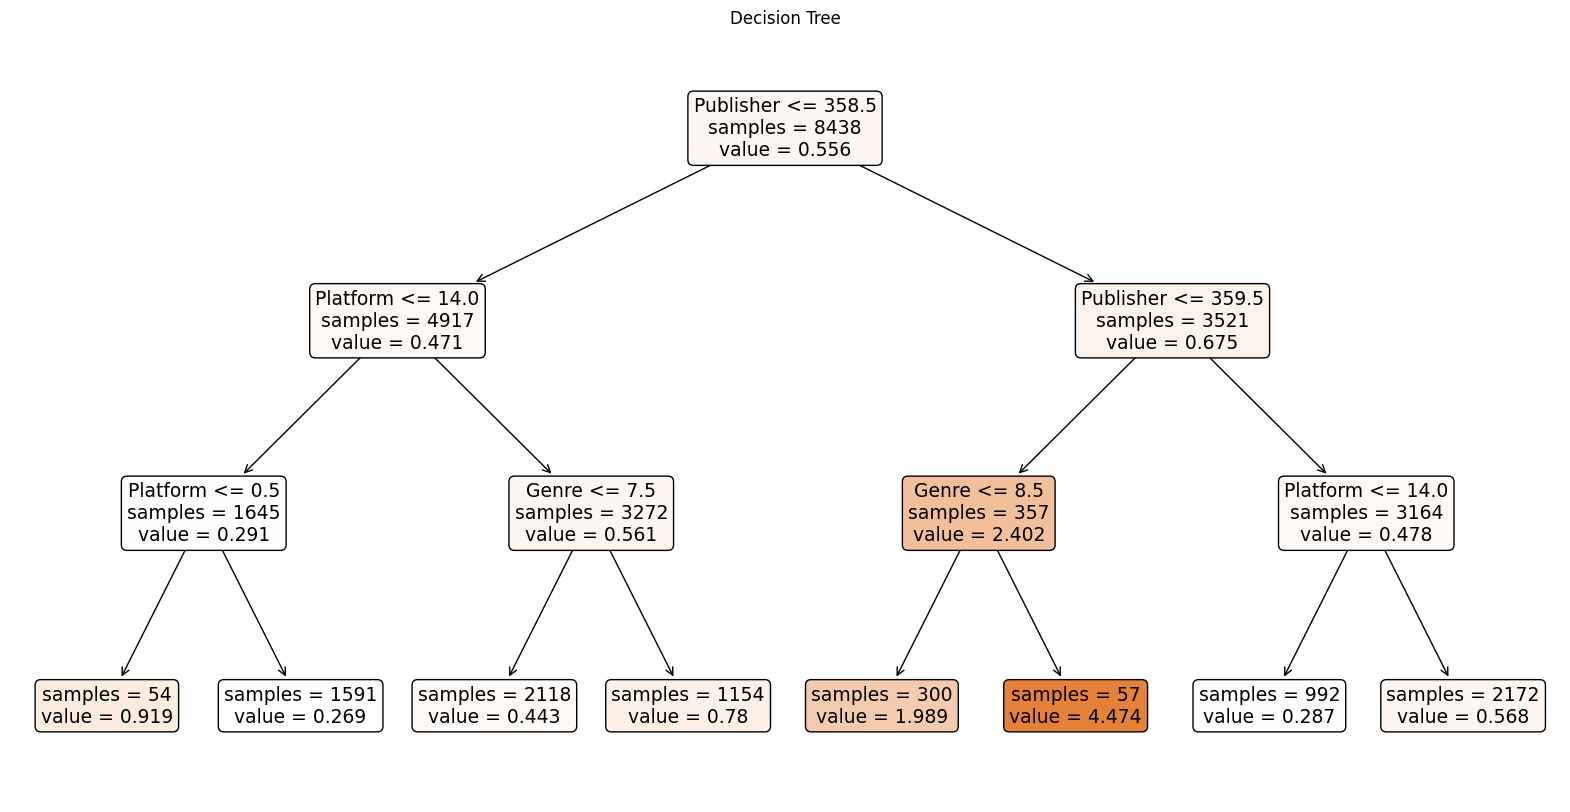

In [97]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

#creating and training Random Forest Regressor for plotting
plot = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=1)

#training the Random Forest model using the training data
plot.fit(X_train, y_train)

dec_tree = plot.estimators_[0]

#setting up the figure size for better visualization
plt.figure(figsize=(20, 10))

#visualizing the decision tree using plot_tree
plot_tree(
    dec_tree,
    feature_names=X_train.columns,  
    impurity=False,                
    filled=True,                  
    rounded=True                   
)

plt.title('Decision Tree')

plt.show()